# Data Fundamentals Lab
In this lab, we will practice all the foundational aspects of working with data that we have covered so far in the course.

All  of  the  programming  assignments  are  to  be  done  in  Python  using  additional  libraries  specified  in  the  assignments.  There  are many  libraries  available,  some  of  which  we  will  be  using,  and  you  are  welcome  to  use  them  with  one  exception:  if  the  library  or  a  function  within  it  performs  the  specific  function  you  are  asked  to  code,  you  may  not  use  that  other  than  as  a  reference  to  compare  against. All  of  the  code  you  submit  must  be  your  own. Once you have completed an assignment, turn in your jupyter notebook with all the outputs shown.


### Preliminaries

Before you begin, make sure you have a properly operating Python environment with the Pandas, NumPy, and Matplotlib packages installed. If setup correctly, the following line of code should run without error:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Also make sure you have the following datasets downloaded from the assignment page and placed in a `datasets/` directory of your project folder. **Please do not change the folder structure to minimize issues when grading.**

In [2]:
penguins_fn = './datasets/penguins.csv'
pokemon_fn = './datasets/pokemon.csv'
movies_fn = './datasets/movies.csv'

Datasets descriptions

- Penguins: Contains biological information about individual penguins of different species on three different islands.
- Pokemon: Contains attack, defense, and other stats information for all pokemon of the famous Pokemon game.
- Movies: Contains financial, IMDB scores, and other info for movies that made over $50,000,000 between 2000-2024.

## Part 1: Load, Inspect, and Clean the Data

For the first part of the lab, we will be using the Penguins dataset.  We need to load this data, inspect it, and remove or replace values that are missing in our data.

In the cell below, write code that will do the following:
- Load the data as a Pandas Dataframe
- Inspect the data to see how missing values are represented within the data
- Count the number of missing values in the Bill Length column
- Remove all rows that are missing values for Bill Length
- Count the number of missing entries in the Sex column
- Sort the data frame by Body Mass and fill in the missing Sex entries with the same value of the penguin closest in Body Mass (back fill order)
- Verify the number of rows matches what is expected and that no missing data values exist in the data frame

You are also welcome to use a tool like Data Wrangler in VS Code to verify that each step is processing correctly.


In [3]:
# load data
penguins_df = pd.read_csv(penguins_fn)
#print(penguins_df)
#print(penguins_df.info())

# count number of missing values in "Bill Length" column
bill_length_df = penguins_df['Bill Length (mm)']
print('There are', bill_length_df.isnull().sum(), 'missing values in the \'Bill Length (mm)\' column')

# remove rows where "Bill Length" is null
penguins_df_bill_not_null = penguins_df.dropna(axis=0, subset=['Bill Length (mm)'])
#print(penguins_df_bill_not_null.head())

# count number of missing values in 'Sex' column
sex_df = penguins_df_bill_not_null['Sex']
print('There are', sex_df.isnull().sum(), 'missing values in the \'Sex\' column')

# sort data frame by body mass
penguins_df_sort_mass = penguins_df_bill_not_null.sort_values(by='Body Mass (g)')
#print(penguins_df_sort_mass)

# fill 'Sex' column with values
penguins_df_sort_mass_not_null_sex = penguins_df_sort_mass.fillna(method='bfill')
#print(penguins_df_sort_mass_not_null_sex)

# output number of rows and counts of missing values
print('There are', len(penguins_df_sort_mass_not_null_sex), 'rows in the final dataframe')
print('Counts of missing values:\n', penguins_df_sort_mass_not_null_sex.isnull().sum())

There are 2 missing values in the 'Bill Length (mm)' column
There are 9 missing values in the 'Sex' column
There are 342 rows in the final dataframe
Counts of missing values:
 Species                0
Island                 0
Bill Length (mm)       0
Bill Depth (mm)        0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Year                   0
dtype: int64


C:\Users\Braxt\AppData\Local\Temp\ipykernel_22360\324230680.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  penguins_df_sort_mass_not_null_sex = penguins_df_sort_mass.fillna(method='bfill')


## Part 2: Analyze and Visualize - Individual Properties

To begin your analysis, let's start by analyzing the body mass distributions for each species of penguin in our dataset.

In the cell below, write code that will do the following:
- Create a pie chart counting the percentage of species in each category
- Create seperate dataframe for each species
- Compute and print the average body mass for each species
- Compute and print the standard deviation in body mass for each species
- Plot the histograms showing the distribution of body mass for each species (plot on the same chart with the same 20 bins)

Remember, you should only be using Pandas, Numpy, and Matplotlib to complete these steps. Do not use any other external packages.

Average body mass (g) for Adelie: 3700.662251655629
Average body mass (g) for Gentoo: 5076.016260162602
Average body mass (g) for Chinstrap: 3733.0882352941176
Standard deviation of body mass for Adelie: 458.5661259101348
Standard deviation of body mass for Gentoo: 504.11623665709163
Standard deviation of body mass for Chinstrap: 384.3350813871914


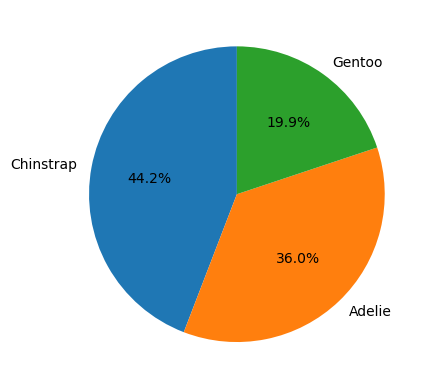

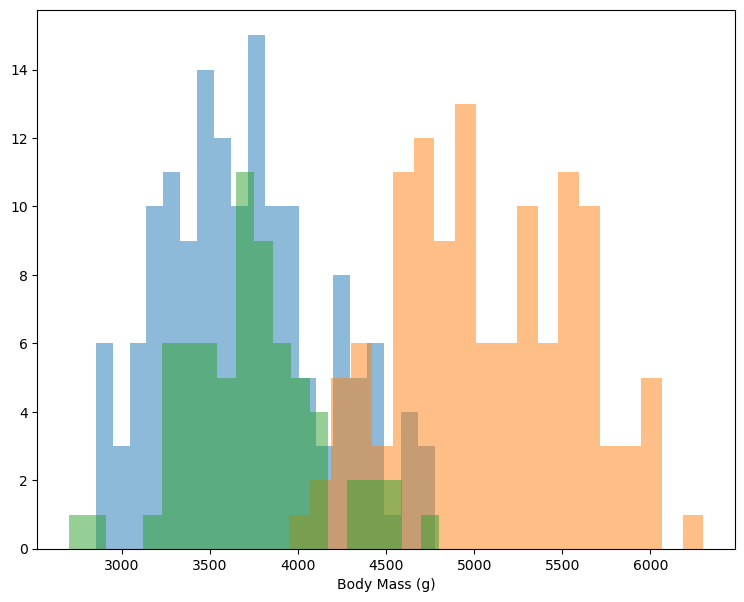

In [4]:
latest_penguins_df = penguins_df_sort_mass_not_null_sex

# create pie chart for percentage of each species
species = latest_penguins_df['Species'].unique()

# create dataframes for each species
adelie_df = latest_penguins_df[latest_penguins_df['Species'] == 'Adelie']
gentoo_df = latest_penguins_df[latest_penguins_df['Species'] == 'Gentoo']
chinstrap_df = latest_penguins_df[latest_penguins_df['Species'] == 'Chinstrap']

pops = [len(adelie_df), len(gentoo_df), len(chinstrap_df)]

plt.pie(pops, labels=species, startangle=90, autopct='%1.1f%%')

# average body mass for each species
print("Average body mass (g) for Adelie:", adelie_df['Body Mass (g)'].mean())
print("Average body mass (g) for Gentoo:", gentoo_df['Body Mass (g)'].mean())
print("Average body mass (g) for Chinstrap:", chinstrap_df['Body Mass (g)'].mean())

# standard deviation of body mass for each species
print("Standard deviation of body mass for Adelie:", adelie_df['Body Mass (g)'].std())
print("Standard deviation of body mass for Gentoo:", gentoo_df['Body Mass (g)'].std())
print("Standard deviation of body mass for Chinstrap:", chinstrap_df['Body Mass (g)'].std())

# create histogram for distribution of body mass for each species
plt.figure(figsize=(9,7))
plt.hist(adelie_df["Body Mass (g)"], bins=20, label="Adelie", alpha=0.5)
plt.hist(gentoo_df["Body Mass (g)"], bins=20, label="Gentoo", alpha=0.5)
plt.hist(chinstrap_df["Body Mass (g)"], bins=20, label="Chinstrap", alpha=0.5)
plt.xlabel("Body Mass (g)")
plt.show()

#### Answer the following questions in the markdown cell below: 

#### Which species had the largest average body mass? Which species has the biggest spread in body mass? What else is interesting about the distributions of body mass?

Gentoo has the largest average body mass and biggest spread in mass. Adelie and Chinstrap have about the same average body mass but quite different distributions.

## Part 3: Analyze and Visualize - Correlations
Flipper length and body mass are highly correlated in most penguins species. We want to verify if the same holds true for our dataset. We will test this over all the penguins, as well as for each species. 

In the cell below, write code that will do the following:
- Create a scatter plot comparing flipper length to body mass for every penguin
- Compute and print the correlation coefficient between flipper length and body mass over all the penguins
- Create a scatter plot comparing flipper length to body mass, colored by species
- Compute and print the correlation coefficient between flipper length and body mass for each individual species

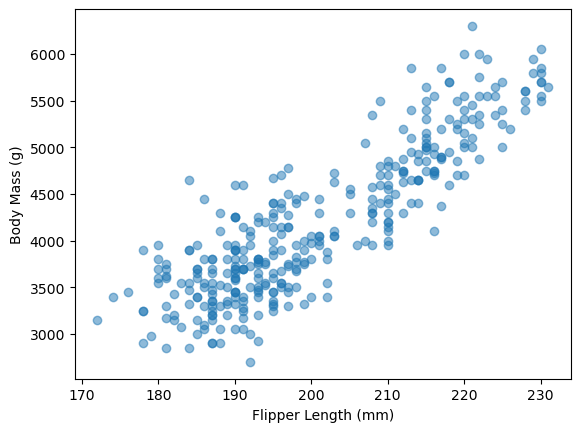

Correlation coefficient between flipper length and body mass is 0.8712017673060113


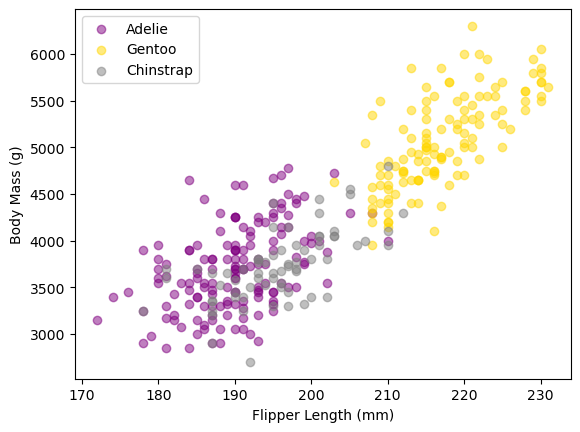

Correlation Coefficient
Adelie: 0.46820169421793956
Gentoo: 0.7026665243575183
Chinstrap: 0.6415594129316968


In [5]:
# create scatter plot to compare flipper length to body mass
flipper_df = latest_penguins_df['Flipper Length (mm)']
body_mass_df = latest_penguins_df['Body Mass (g)']

plt.scatter(flipper_df, body_mass_df, alpha=0.5)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

# correlation coefficient
print("Correlation coefficient between flipper length and body mass is", np.corrcoef(flipper_df, body_mass_df)[0][1])

# create scatter plot to compare flipper length to body mass, colored by species
flipper_adelie_df = adelie_df['Flipper Length (mm)']
flipper_gentoo_df = gentoo_df['Flipper Length (mm)']
flipper_chinstrap_df = chinstrap_df['Flipper Length (mm)']

body_mass_adelie_df = adelie_df['Body Mass (g)']
body_mass_gentoo_df = gentoo_df['Body Mass (g)']
body_mass_chinstrap_df = chinstrap_df['Body Mass (g)']

plt.scatter(flipper_adelie_df, body_mass_adelie_df, c="purple", label="Adelie", alpha=0.5)
plt.scatter(flipper_gentoo_df, body_mass_gentoo_df, c="gold", label="Gentoo", alpha=0.5)
plt.scatter(flipper_chinstrap_df, body_mass_chinstrap_df, c="grey", label="Chinstrap", alpha=0.5)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend()
plt.show()

# correlation coefficient between flipper length and body mass for each species
print("Correlation Coefficient")
print("Adelie:", np.corrcoef(flipper_adelie_df, body_mass_adelie_df)[0][1])
print("Gentoo:", np.corrcoef(flipper_gentoo_df, body_mass_gentoo_df)[0][1])
print("Chinstrap:", np.corrcoef(flipper_chinstrap_df, body_mass_chinstrap_df)[0][1])

#### Answer the following questions in the markdown cell below: 

#### Which species had the least correlation between flipper length and body mass? How is it possible that the correlations for each individual species is lower than the correlation over all species?

Adelie has the least correlation between flipper length and body mass.

## Part 4: Analyze and Visualize - Finding Predictors
Imagine that we want to build a classifier that correctly predicts the species of a penguin based on two simple measurements of the penguin. For example, if you analyze the data from part 3, you might notice that Gentoo penguins have larger Flipper Length and Body Mass than the other two penguins species. In other words, these properites help separate this class of penguins from others. It is an important skill for machine learning to find properties that could be helpful in separating subgroups and being useful for prediction problems.

The flipper length/body mass predictor would work well for classifying a Gentoo penguin, but not help us separate between Adelie and Chinstrap penguins. We want to find a predictor for every species, and we want to find another predictor for sex. Analyze and visualize the data to see if you can find separable properties for these two problems. 

In the cell below, write code that will do the following:
- Create a scatter plot comparing one measurement vs another measurement, colored by species
- Create a scatter plot comparing one measurement vs another measurement, colored by sex
- Repeat these steps until you find two measurements that you believe could accuractly separate penguins by species or by sex for our dataset


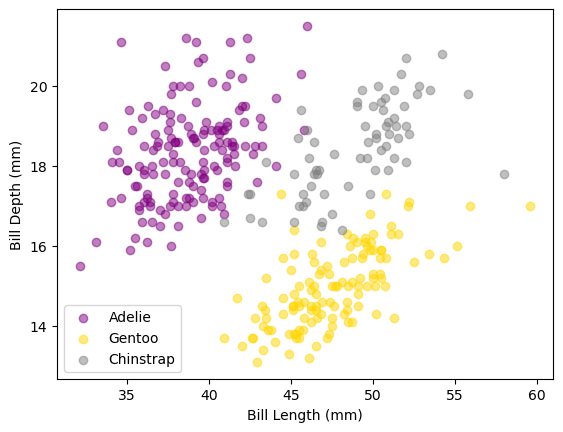

Adelie: 0.3914916918358767
Gentoo: 0.643383946525338
Chinstrap: 0.6535362081800429
       Species  Island  Bill Length (mm)  Bill Depth (mm)  \
314  Chinstrap   Dream              46.9             16.6   
58      Adelie  Biscoe              36.5             16.6   
64      Adelie  Biscoe              36.4             17.1   
54      Adelie  Biscoe              34.5             18.1   
98      Adelie   Dream              33.1             16.1   
..         ...     ...               ...              ...   
263     Gentoo  Biscoe              49.8             15.9   
269     Gentoo  Biscoe              48.8             16.2   
229     Gentoo  Biscoe              51.1             16.3   
185     Gentoo  Biscoe              59.6             17.0   
169     Gentoo  Biscoe              49.2             15.2   

     Flipper Length (mm)  Body Mass (g)     Sex  Year  
314                192.0         2700.0  female  2008  
58                 181.0         2850.0  female  2008  
64              

ValueError: x and y must be the same size

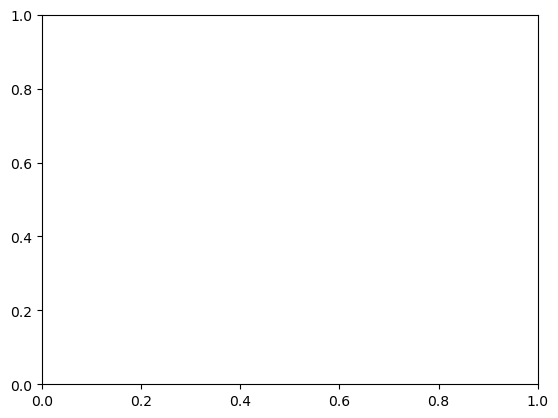

In [6]:
# create scatter plot to compare by species
col1 = 'Bill Length (mm)'
col2 = 'Bill Depth (mm)'

test1_adelie_df = adelie_df[col1]
test1_gentoo_df = gentoo_df[col1]
test1_chinstrap_df = chinstrap_df[col1]

test2_adelie_df = adelie_df[col2]
test2_gentoo_df = gentoo_df[col2]
test2_chinstrap_df = chinstrap_df[col2]

plt.scatter(test1_adelie_df, test2_adelie_df, c="purple", label="Adelie", alpha=0.5)
plt.scatter(test1_gentoo_df, test2_gentoo_df, c="gold", label="Gentoo", alpha=0.5)
plt.scatter(test1_chinstrap_df, test2_chinstrap_df, c="grey", label="Chinstrap", alpha=0.5)
plt.xlabel(col1)
plt.ylabel(col2)
plt.legend()
plt.show()

print("Adelie:", np.corrcoef(test1_adelie_df, test2_adelie_df)[0][1])
print("Gentoo:", np.corrcoef(test1_gentoo_df, test2_gentoo_df)[0][1])
print("Chinstrap:", np.corrcoef(test1_chinstrap_df, test2_chinstrap_df)[0][1])

# create scatter plot to compare by sex
col1 = 'Flipper Length (mm)'
col2 = 'Body Mass (g)'

male_df = latest_penguins_df[latest_penguins_df['Sex'] == 'male']
female_df = latest_penguins_df[latest_penguins_df['Sex'] == 'female']

print(latest_penguins_df)

test1_male_df = male_df[col1]
test1_female_df = female_df[col1]

test2_male_df = male_df[col2]
test2_female_df = female_df[col2]

plt.scatter(test1_male_df, test2_female_df, c="purple", label="Male", alpha=0.5)
plt.scatter(test1_male_df, test2_female_df, c="gold", label="Female", alpha=0.5)
plt.xlabel(col1)
plt.ylabel(col2)
plt.legend()
plt.show()

print("Adelie:", np.corrcoef(test1_male_df, test2_female_df)[0][1])
print("Gentoo:", np.corrcoef(test1_male_df, test2_female_df)[0][1])

#### Answer the following questions in the markdown cell below: 

#### What two measurements did you find that would best separate penguins by species? What two measurements did you find that would separate penguins by sex? What visual indications did you look for? What might be one mathematical way you could try to verify the accuracy of your separations?

## Part 5: Exploring a Dataset

For this last part of the lab, you will practice finding interesting properties, trends, correlations, and predictors on your own. Take either the Pokemon dataset or the Movies dataset (whichever you find most interesting) and start exploring it. You need to present and/or hypothesize the following:

- At least two interesting properties or trends in the dataset.
- At least one correlation that is present in the dataset. Alternatively, find an interesting correlation that doesn't exist that might be expected.
- At least one property that could be a possible predictor between categories in the datset.

Present your findings in the code and markup cells that follow. Use print statements and plots to justify your arguments. Make sure your findings are neatly organized and easy for the grader to find. For this section, you will be graded on your presentation quality in addition to the correctness of your code.

*Note: In the movies dataset, if you want to grab the data for a single genre, you can use the code: `df = movies[movies["Genres"].str.contains(keyword, na=False)]`.*

In [ ]:
movies = pd.read_csv(movies_fn)



### Individual Property

The number of total movies that made over $50,000,000 is significantly lower in 2020. This is likely due to the COVID-19 pandemic. Also, the number of romance movies making over $50,000,000 is lowering over time. This may be an artifact of streaming platforms being seen as the main venue for genres such as romance.

Another interesting property of the dataset is that Inside Out 2 is the only non action movie in the top 10 of domestic grossing movies in the dataset.

In [ ]:
# Get the number of total movies by year
total_counts = movies["Year"].value_counts().sort_index()
plt.plot(total_counts.index, total_counts.values)

NameError: name 'movies' is not defined

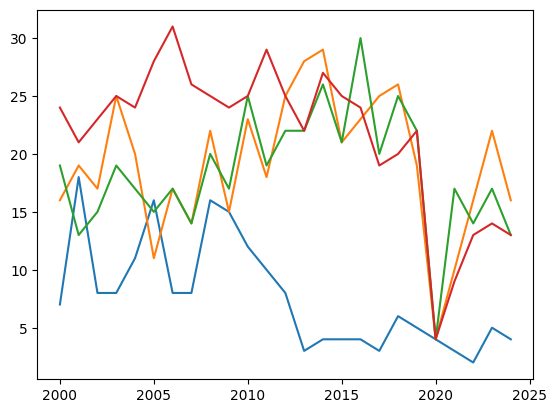

In [ ]:
# Get the number of romance movies by year
romance_df = movies[movies["Genres"].str.contains("Romance", na=False)]
romance_counts = romance_df["Year"].value_counts().sort_index()
plt.plot(romance_counts.index, romance_counts.values)

# Get the number of action movies by year
action_df = movies[movies["Genres"].str.contains("Action", na=False)]
action_counts = action_df["Year"].value_counts().sort_index()
plt.plot(action_counts.index, action_counts.values)

# Get the number of adventure movies by year
adventure_df = movies[movies["Genres"].str.contains("Adventure", na=False)]
adventure_counts = adventure_df["Year"].value_counts().sort_index()
plt.plot(adventure_counts.index, adventure_counts.values)

# Get the number of comedy movies by year
comedy_df = movies[movies["Genres"].str.contains("Comedy", na=False)]
comedy_counts = comedy_df["Year"].value_counts().sort_index()
plt.plot(comedy_counts.index, comedy_counts.values)

In [ ]:
# Sort movies by domestic gross
movies = movies.sort_values("$Domestic", ascending=False)

print(movies[["Release Group", "$Domestic","Genres"]][:10])

                                   Release Group    $Domestic  \
904   Star Wars: Episode VII - The Force Awakens  936662225.0   
1138                           Avengers: Endgame  858373000.0   
1203                     Spider-Man: No Way Home  804793477.0   
508                                       Avatar  749766139.0   
1229                           Top Gun: Maverick  718732821.0   
1082                               Black Panther  700059566.0   
1228                    Avatar: The Way of Water  684075767.0   
1081                      Avengers: Infinity War  678815482.0   
1311                                Inside Out 2  652980194.0   
905                               Jurassic World  652270625.0   

                                            Genres  
904             Adventure, Action, Science Fiction  
1138            Adventure, Science Fiction, Action  
1203            Action, Adventure, Science Fiction  
508    Action, Adventure, Fantasy, Science Fiction  
1229               

### Correlation Example

Suprisingly, there is not a strong correlation between how much a movie makes and well it is rated by audiences.

Correlation coefficient between Rating and Domestic Gross: 0.3176066486203301


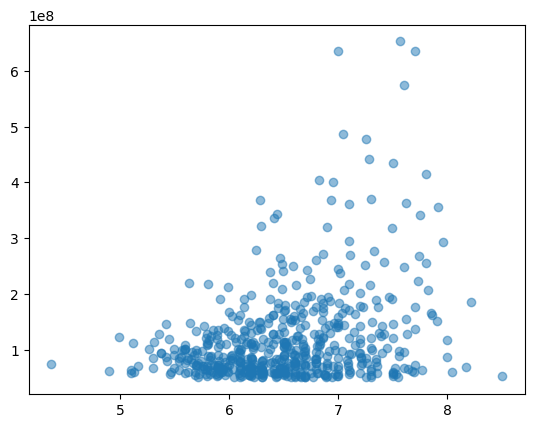

In [ ]:
# Compute correlation coefficient rating and domestic gross
correlation = df["Rating"].astype(float).corr(df["$Domestic"].astype(float))
print(f"Correlation coefficient between Rating and Domestic Gross: {correlation}")

plt.scatter( df["Rating"], df["$Domestic"], alpha=0.5, label=keyword)
plt.show()

### Predictor Example

The comedy genre appears to make the least amount of money and have most of its audience domestically. This might separate effectively from the action genre which has a lot of audience oversees and makes a lot more money total.

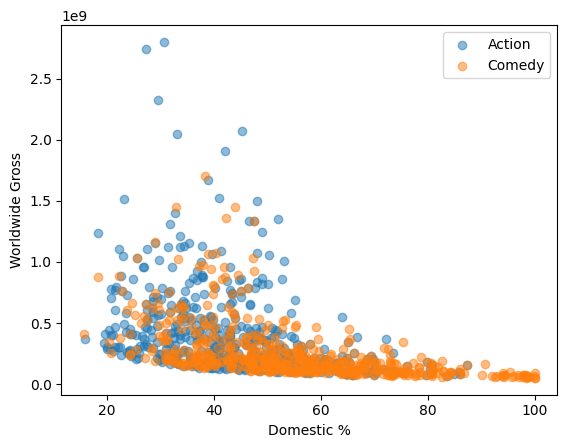

In [ ]:
# Grab rows by movies that contain specific genres keywords
cat_labels = ["Action", "Comedy"]

for keyword in cat_labels:
    df = movies[movies["Genres"].str.contains(keyword, na=False)]
    plt.scatter(df["Domestic %"], df["$Worldwide"], alpha=0.5, label=keyword)
plt.xlabel('Domestic %')
plt.ylabel('Worldwide Gross')
plt.legend()
plt.show()